In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [88]:
df = pd.read_csv('diabetes.csv')
df.shape       # show number of rows and columns
df.info()      # show column names and data types
df.describe()  # show basic statistics

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [89]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [90]:
df[df['Outcome']==1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
755,1,128,88,39,110,36.5,1.057,37,1
757,0,123,72,0,0,36.3,0.258,52,1
759,6,190,92,0,0,35.5,0.278,66,1
761,9,170,74,31,0,44.0,0.403,43,1


In [91]:
df.columns[:]

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

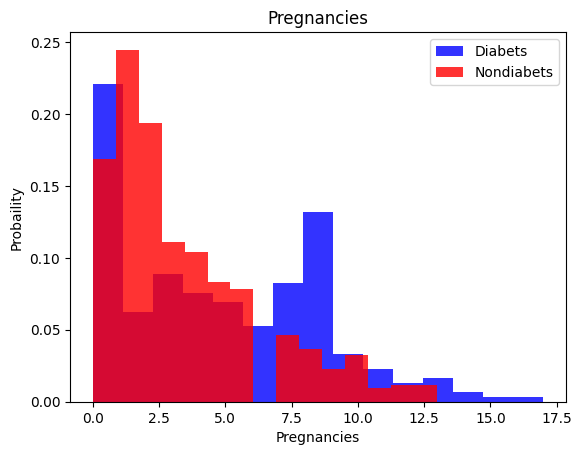

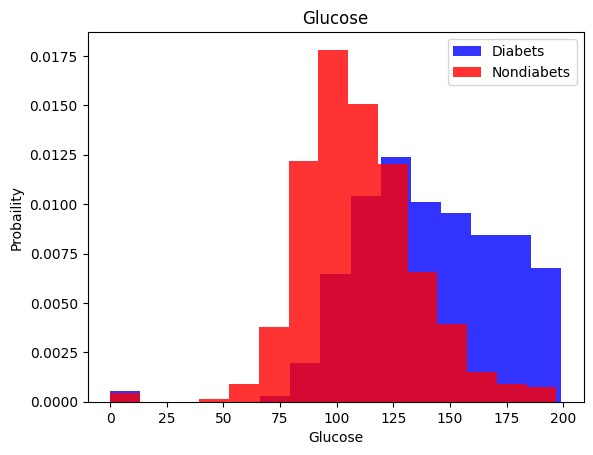

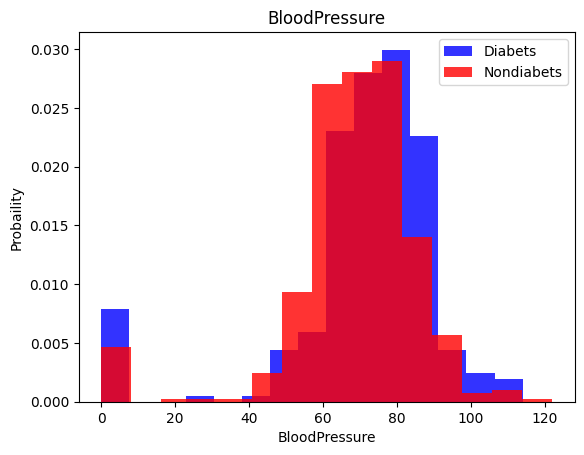

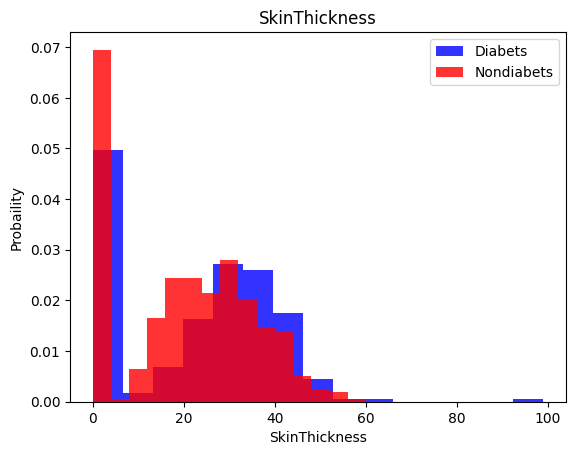

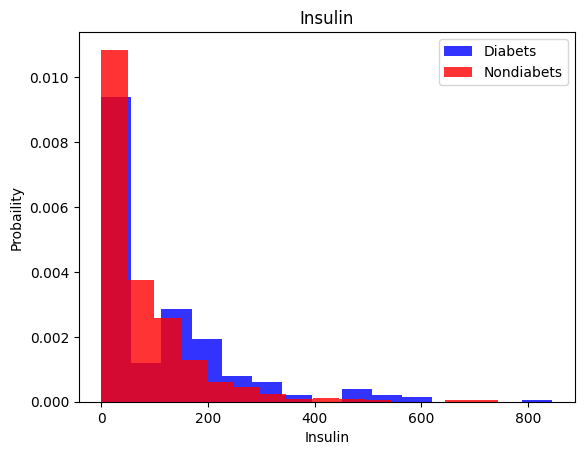

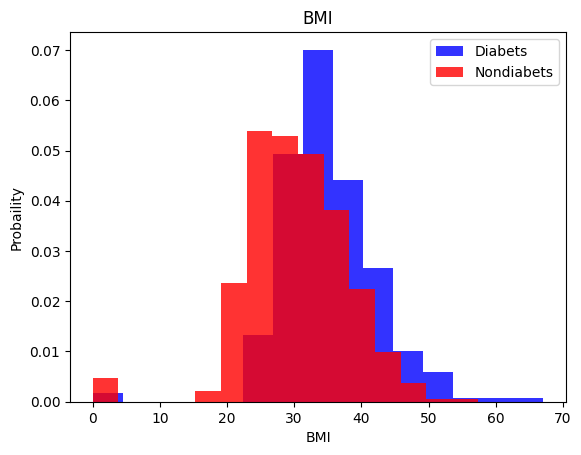

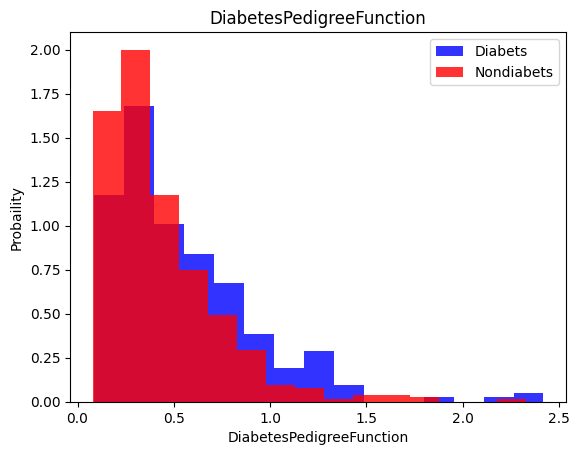

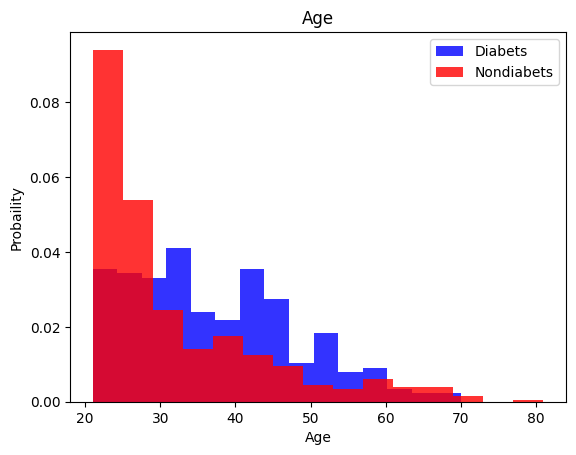

In [92]:
for i in range(len(df.columns[:-1])):
    label = df.columns[i]
    plt.hist(df[df['Outcome']==1][label] , color = 'blue' , label = 'Diabets' , alpha = 0.8 , density = True , bins = 15)
    plt.hist(df[df['Outcome']==0][label] , color = 'red' , label = 'Nondiabets' , alpha = 0.8 , density = True , bins = 15)
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('Probaility')
    plt.legend()
    plt.show()

In [93]:
df[df['Outcome']==1]['Glucose']

0      148
2      183
4      137
6       78
8      197
      ... 
755    128
757    123
759    190
761    170
766    126
Name: Glucose, Length: 268, dtype: int64

In [94]:
# Features(Input) , what the model sees
X = df[df.columns[:-1]].values
# Output (Predictions) , what the model learn
y = df[df.columns[-1]].values
X.shape , y.shape

((768, 8), (768,))

In [95]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

data = np.hstack((X , np.reshape(y , (-1 , 1))))

transform_df = pd.DataFrame(data , columns=df.columns)

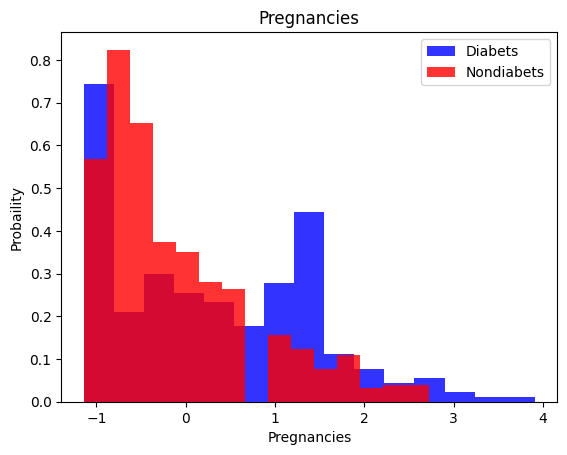

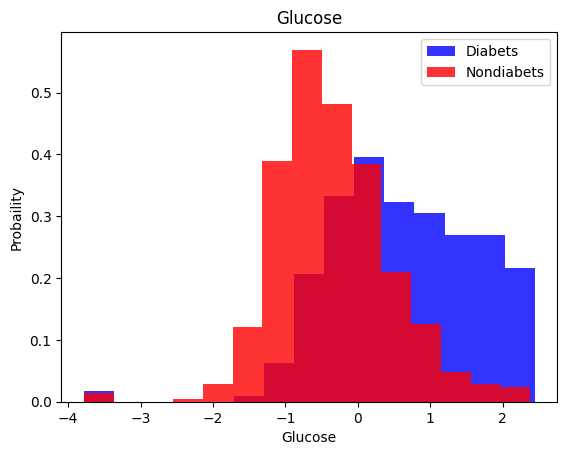

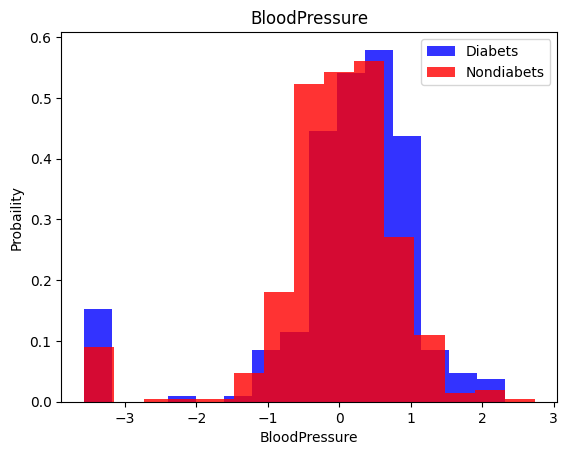

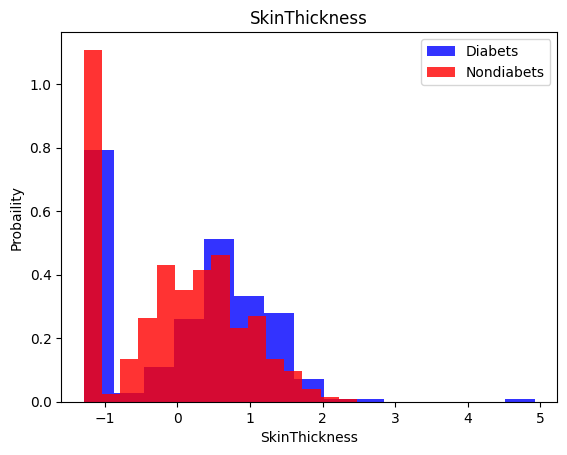

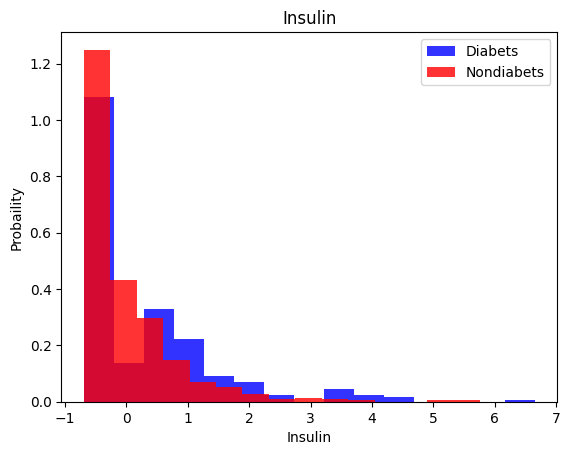

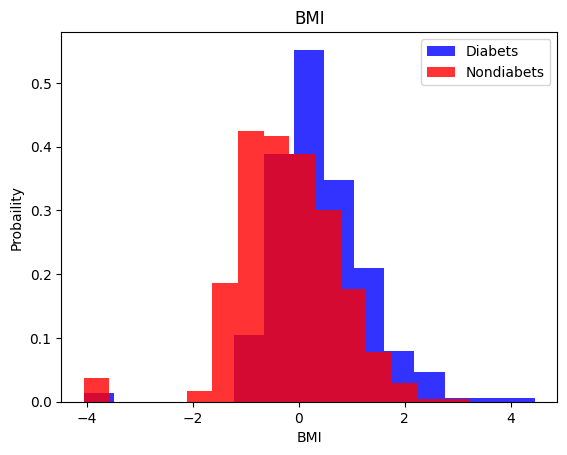

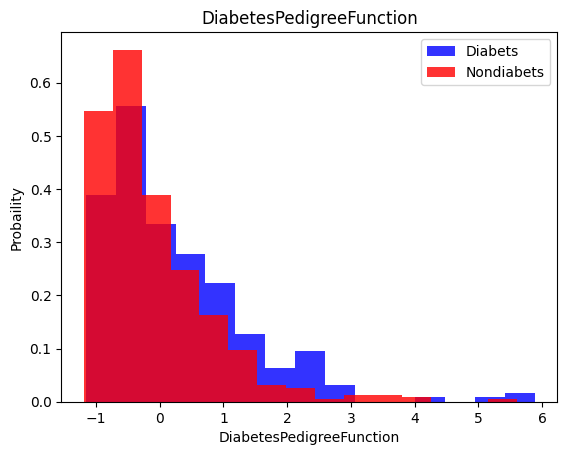

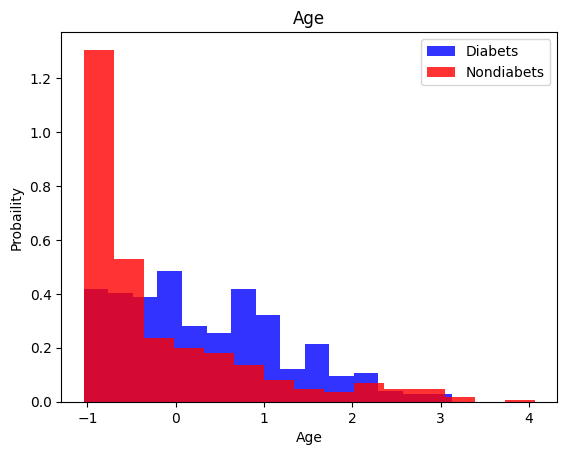

In [96]:
for i in range(len(df.columns[:-1])):
    label = df.columns[i]
    plt.hist(transform_df[transform_df['Outcome']==1][label] , color = 'blue' , label = 'Diabets' , alpha = 0.8 , density = True , bins = 15)
    plt.hist(transform_df[transform_df['Outcome']==0][label] , color = 'red' , label = 'Nondiabets' , alpha = 0.8 , density = True , bins = 15)
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('Probaility')
    plt.legend()
    plt.show()

In [97]:
transform_df.shape

over = RandomOverSampler()

X , y = over.fit_resample(X , y)
X.shape , y.shape

((1000, 8), (1000,))

In [98]:
len(transform_df[transform_df['Outcome']==1]) , len(transform_df[transform_df['Outcome']==0])

(268, 500)

In [99]:
# 60% for train , 40% for further spliting
x_tarin , x_temp , y_train , y_temp = train_test_split(X , y , test_size=0.4 , random_state=0)
# 20% to tune and compare models , 20% for final validation
x_validation , x_test , y_validation , y_test = train_test_split(x_temp , y_temp , test_size=0.5 , random_state=0)

In [100]:
# the neurn net
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16 , activation='relu'),
    tf.keras.layers.Dense(16 , activation='relu'),
    tf.keras.layers.Dense(1 , activation='sigmoid')
])

In [ ]:
# 1. How does the model FIX its mistakes?  → optimizer
# 2. How does the model MEASURE mistakes?  → loss
# 3. How do WE measure success?            → metrics
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy']
)

In [102]:
model.evaluate(x_tarin , y_train)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5567 - loss: 0.6988  


[0.6987826824188232, 0.5566666722297668]

In [103]:
model.evaluate(x_validation , y_validation)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6100 - loss: 0.7014 


[0.7013543844223022, 0.6100000143051147]

In [104]:
model.fit(x_tarin , y_train , batch_size=16 , epochs=20 , validation_data=(x_validation , y_validation))

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5883 - loss: 0.6740 - val_accuracy: 0.6600 - val_loss: 0.6406
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6683 - loss: 0.6303 - val_accuracy: 0.7200 - val_loss: 0.5963
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6967 - loss: 0.5987 - val_accuracy: 0.7450 - val_loss: 0.5598
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7067 - loss: 0.5731 - val_accuracy: 0.7650 - val_loss: 0.5336
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7317 - loss: 0.5519 - val_accuracy: 0.7750 - val_loss: 0.5145
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7417 - loss: 0.5364 - val_accuracy: 0.7700 - val_loss: 0.5013
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7533 - loss: 0.5242 - val_accuracy: 0.7800 - val_loss: 0.4903
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7633 - loss: 0.5152 - val_accuracy: 0.7950 - val_loss:

In [105]:
model.evaluate(x_test , y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7700 - loss: 0.4831 


[0.48309290409088135, 0.7699999809265137]